# DCLM-Edu OptiSelect Benchmark Plotter

This notebook makes publication-ready plots from `demo_DCLM.sh` / `demo_dclm_ddp.py` result folders. It is designed for fair comparisons between each standard optimizer and its OptiSelect counterpart.

The main fairness convention is:

- `update_tokens`: tokens that actually update model parameters. This measures selected-data efficiency.
- `processed_tokens`: update tokens plus candidate-scoring tokens. This measures implementation/data-processing cost.
- final bars and pair-ratio plots use the exact budgets written in each run's `summary.json`.

Set `RUN_DIRS` below to one or more result directories, for example `results/demo_dclm_optiselect_sophia_ddp2_h100_seed42`. If `AUTO_DISCOVER_COUNTERPARTS=True`, the notebook searches nearby result folders for the missing standard/OptiSelect pair with matching model, dataset, seed, and DDP world size.

In [1]:
from pathlib import Path
import os

from IPython.display import Image, Markdown, display

from demo_plot_utils import (
    REPO_ROOT,
    RESULTS_ROOT,
    load_demo_results,
    load_lm_eval_metrics,
    make_publication_plots,
    plot_lm_eval_metrics,
)

# Edit this list for the runs you want to compare. Relative paths like
# "results/..." resolve against /mloscratch/homes/aabdolla/results.
RUN_DIRS = [
    # "results/demo_optiselect_dclm_edu_comprehensive/optiselect_adamw",
    # "results/demo_dclm_standrad_ademamix_ddp2_h100_seed42",
    # "results/demo_dclm_optiselect_ademamix_ddp2_h100_seed42",
    # "results/demo_dclm_optiselect_adamw_ddp2_h100_seed42",
    # "results/demo_dclm_standrad_adamw_ddp2_h100_seed42"
    "results/demo_dclm_adamw_equal1B_downstreamproxy_hs_arc_obqa_ddp2_h200_seed42",
    "results/demo_dclm_adamw_equal1B_ddp4_h100_seed42/adamw",
    "results/demo_dclm_ademamix_equal1B_downstreamproxy_hs_arc_obqa_ddp2_h200_seed42/optiselect_ademamix",
    "results/demo_dclm_ademamix_equal1B_ddp4_a100_seed42/ademamix",
    "results/demo_dclm_muon_equal1B_downstreamproxy_hs_arc_obqa_ddp2_a100_seed42/optiselect_d-muon",
    "results/demo_dclm_muon_equal1B_ddp4_h200_seed42/d-muon",
    "results/demo_optiselect_dclm_edu_comprehensive/optiselect_signsgd",
    
]

# Optional: set DEMO_PLOT_RUN_DIRS="path1,path2,path3" before launching Jupyter.
env_dirs = os.environ.get("DEMO_PLOT_RUN_DIRS")
if env_dirs:
    RUN_DIRS = [p.strip() for p in env_dirs.split(",") if p.strip()]

AUTO_DISCOVER_COUNTERPARTS = True
# Keep this as None for the safest default: the loader searches the parent
# directory of each requested run plus the repo-local results root.
SEARCH_ROOTS = None
OUTPUT_DIR = REPO_ROOT / "src" / "figures" / "demo_dclm_publication"
FIG_FORMATS = ("pdf", "png")
INCLUDE_TRAIN_CURVES = True

display(Markdown("### Requested result directories"))
for p in RUN_DIRS:
    print(p)
print(f"\nOutput directory: {OUTPUT_DIR.resolve()}")

### Requested result directories

results/demo_dclm_adamw_equal1B_downstreamproxy_hs_arc_obqa_ddp2_h200_seed42
results/demo_dclm_adamw_equal1B_ddp4_h100_seed42/adamw
results/demo_dclm_ademamix_equal1B_downstreamproxy_hs_arc_obqa_ddp2_h200_seed42/optiselect_ademamix
results/demo_dclm_ademamix_equal1B_ddp4_a100_seed42/ademamix
results/demo_dclm_muon_equal1B_downstreamproxy_hs_arc_obqa_ddp2_a100_seed42/optiselect_d-muon
results/demo_dclm_muon_equal1B_ddp4_h200_seed42/d-muon
results/demo_optiselect_dclm_edu_comprehensive/optiselect_signsgd

Output directory: /mloscratch/homes/aabdolla/llm-optimizer-benchmark/src/figures/demo_dclm_publication


## 1. Load Runs and Check Fairness

The loader reads every `summary.json` under the requested folders. When counterpart discovery is enabled, it also searches `SEARCH_ROOTS` for missing standard/OptiSelect pairs. The fairness report should be clean before using the figures for a paper or report.

In [2]:
data = load_demo_results(
    RUN_DIRS,
    auto_discover_counterparts=AUTO_DISCOVER_COUNTERPARTS,
    search_roots=SEARCH_ROOTS,
    train_stride=10,
)

display(Markdown(f"Loaded **{len(data.run_df)}** run summaries."))
if data.added_counterparts:
    display(Markdown("### Auto-discovered counterparts"))
    for path in data.added_counterparts:
        print(path)
if data.warnings:
    display(Markdown("### Warnings"))
    for msg in data.warnings:
        print(f"- {msg}")

Loaded **7** run summaries.

### Warnings

- DDP world size: 1, 2, 4
- signSGD has optiselect; missing standard


In [3]:
display(Markdown("### Fairness report"))
display(data.fairness_df)

run_cols = [
    "optimizer_display",
    "mode_display",
    "run_key",
    "seed",
    "accelerator",
    "world_size",
    "steps",
    "actual_update_tokens",
    "actual_processed_tokens",
    "wall_time_sec",
    "peak_vram_gb",
    "final_val_loss",
    "final_val_ppl",
    "summary_path",
]
display(Markdown("### Loaded runs"))
display(
    data.run_df[run_cols]
    .sort_values(["optimizer_display", "mode_display", "seed"])
    .reset_index(drop=True)
)

display(Markdown("### Standard vs OptiSelect pair table"))
if data.pair_df.empty:
    display(Markdown("No complete standard/OptiSelect pairs are available yet."))
else:
    display(data.pair_df)

### Fairness report

,check,status,message
0,model architecture,ok,model architecture: c479728e4d2e
1,dataset fingerprint,ok,dataset fingerprint: d4439064ee534a4b
2,global update batch tokens,ok,global update batch tokens: 131072
3,DDP world size,warn,"DDP world size: 1, 2, 4"
4,adamw pair,ok,"AdamW has optiselect, standard; missing none"
5,d-muon pair,ok,"d-Muon has optiselect, standard; missing none"
6,signsgd pair,warn,signSGD has optiselect; missing standard
7,ademamix pair,ok,"AdEMAMix has optiselect, standard; missing none"


### Loaded runs

,optimizer_display,mode_display,run_key,seed,accelerator,world_size,steps,actual_update_tokens,actual_processed_tokens,wall_time_sec,peak_vram_gb,final_val_loss,final_val_ppl,summary_path
0,AdEMAMix,OptiSelect,optiselect_ademamix,42.0,None,2,7630,1000079360,3000238080,6536.931159,21.692226,3.031781,20.734132,/mloscratch/homes/aabdolla/results/demo_dclm_a...
1,AdEMAMix,Standard,ademamix,42.0,None,4,7630,1000079360,1000079360,1840.506959,12.321568,3.031363,20.725465,/mloscratch/homes/aabdolla/results/demo_dclm_a...
2,AdamW,OptiSelect,optiselect_adamw,42.0,None,2,7630,1000079360,3000238080,6533.040897,21.504723,3.224222,25.134015,/mloscratch/homes/aabdolla/results/demo_dclm_a...
3,AdamW,Standard,adamw,42.0,None,4,7630,1000079360,1000079360,894.256615,12.180695,3.234843,25.402375,/mloscratch/homes/aabdolla/results/demo_dclm_a...
4,d-Muon,OptiSelect,optiselect_d-muon,42.0,None,4,7630,1000079360,3000238080,18153.279918,12.062824,3.082481,21.812443,/mloscratch/homes/aabdolla/results/demo_dclm_m...
5,d-Muon,Standard,d-muon,42.0,None,4,7630,1000079360,1000079360,907.743688,12.086941,3.080695,21.773538,/mloscratch/homes/aabdolla/results/demo_dclm_m...
6,signSGD,OptiSelect,optiselect_signsgd,NaN,None,1,7630,1000079360,3000238080,13406.528203,40.718573,3.779961,43.814349,/mloscratch/homes/aabdolla/results/demo_optise...


### Standard vs OptiSelect pair table

,optimizer,optimizer_display,standard_final_val_loss,optiselect_final_val_loss,delta_val_loss,standard_final_val_ppl,optiselect_final_val_ppl,ppl_ratio,update_token_ratio,processed_token_ratio,wall_time_ratio,peak_vram_delta_gb
0,adamw,AdamW,3.234843,3.224222,-0.010621,25.402375,25.134015,0.989436,1.0,3.0,7.305555,9.324028
1,d-muon,d-Muon,3.080695,3.082481,0.001785,21.773538,21.812443,1.001787,1.0,3.0,19.998244,-0.024117
2,ademamix,AdEMAMix,3.031363,3.031781,0.000418,20.725465,20.734132,1.000418,1.0,3.0,3.551701,9.370659


## 2. Generate Publication Figures

This cell writes vector PDFs plus PNG previews, along with CSV tables for reproducibility. The most important figures are usually:

- `ranking_val_loss_vs_update_tokens`: all optimizer curves on one axes for fast ranking by selected-data efficiency.
- `ranking_val_loss_vs_processed_tokens`: all optimizer curves on one axes for cost-aware ranking including candidate scoring.
- `ranking_val_loss_vs_iterations`: all optimizer curves on one axes over training iterations.
- `val_loss_vs_update_tokens`: small multiples for paired optimizer inspection.
- `val_loss_vs_processed_tokens`: small multiples for cost-aware paired inspection.
- `val_loss_vs_iterations`: small multiples for paired optimizer inspection over training iterations.
- `final_val_loss_bars`: final quality comparison.
- `optiselect_vs_standard_ratios`: paired quality/resource summary.

In [4]:
written = make_publication_plots(
    data,
    OUTPUT_DIR,
    formats=FIG_FORMATS,
    include_train_curves=INCLUDE_TRAIN_CURVES,
)

display(Markdown(f"Wrote **{len(written)}** files to `{OUTPUT_DIR.resolve()}`."))
for path in written:
    print(path)

Wrote **31** files to `/mloscratch/homes/aabdolla/llm-optimizer-benchmark/src/figures/demo_dclm_publication`.

/mloscratch/homes/aabdolla/llm-optimizer-benchmark/src/figures/demo_dclm_publication/run_summary.csv
/mloscratch/homes/aabdolla/llm-optimizer-benchmark/src/figures/demo_dclm_publication/validation_curves.csv
/mloscratch/homes/aabdolla/llm-optimizer-benchmark/src/figures/demo_dclm_publication/train_curves.csv
/mloscratch/homes/aabdolla/llm-optimizer-benchmark/src/figures/demo_dclm_publication/optimizer_pair_table.csv
/mloscratch/homes/aabdolla/llm-optimizer-benchmark/src/figures/demo_dclm_publication/fairness_report.csv
/mloscratch/homes/aabdolla/llm-optimizer-benchmark/src/figures/demo_dclm_publication/val_loss_vs_update_tokens.pdf
/mloscratch/homes/aabdolla/llm-optimizer-benchmark/src/figures/demo_dclm_publication/val_loss_vs_update_tokens.png
/mloscratch/homes/aabdolla/llm-optimizer-benchmark/src/figures/demo_dclm_publication/val_loss_vs_processed_tokens.pdf
/mloscratch/homes/aabdolla/llm-optimizer-benchmark/src/figures/demo_dclm_publication/val_loss_vs_processed_tokens.png
/mloscrat

### `ranking_val_loss_vs_update_tokens.png`

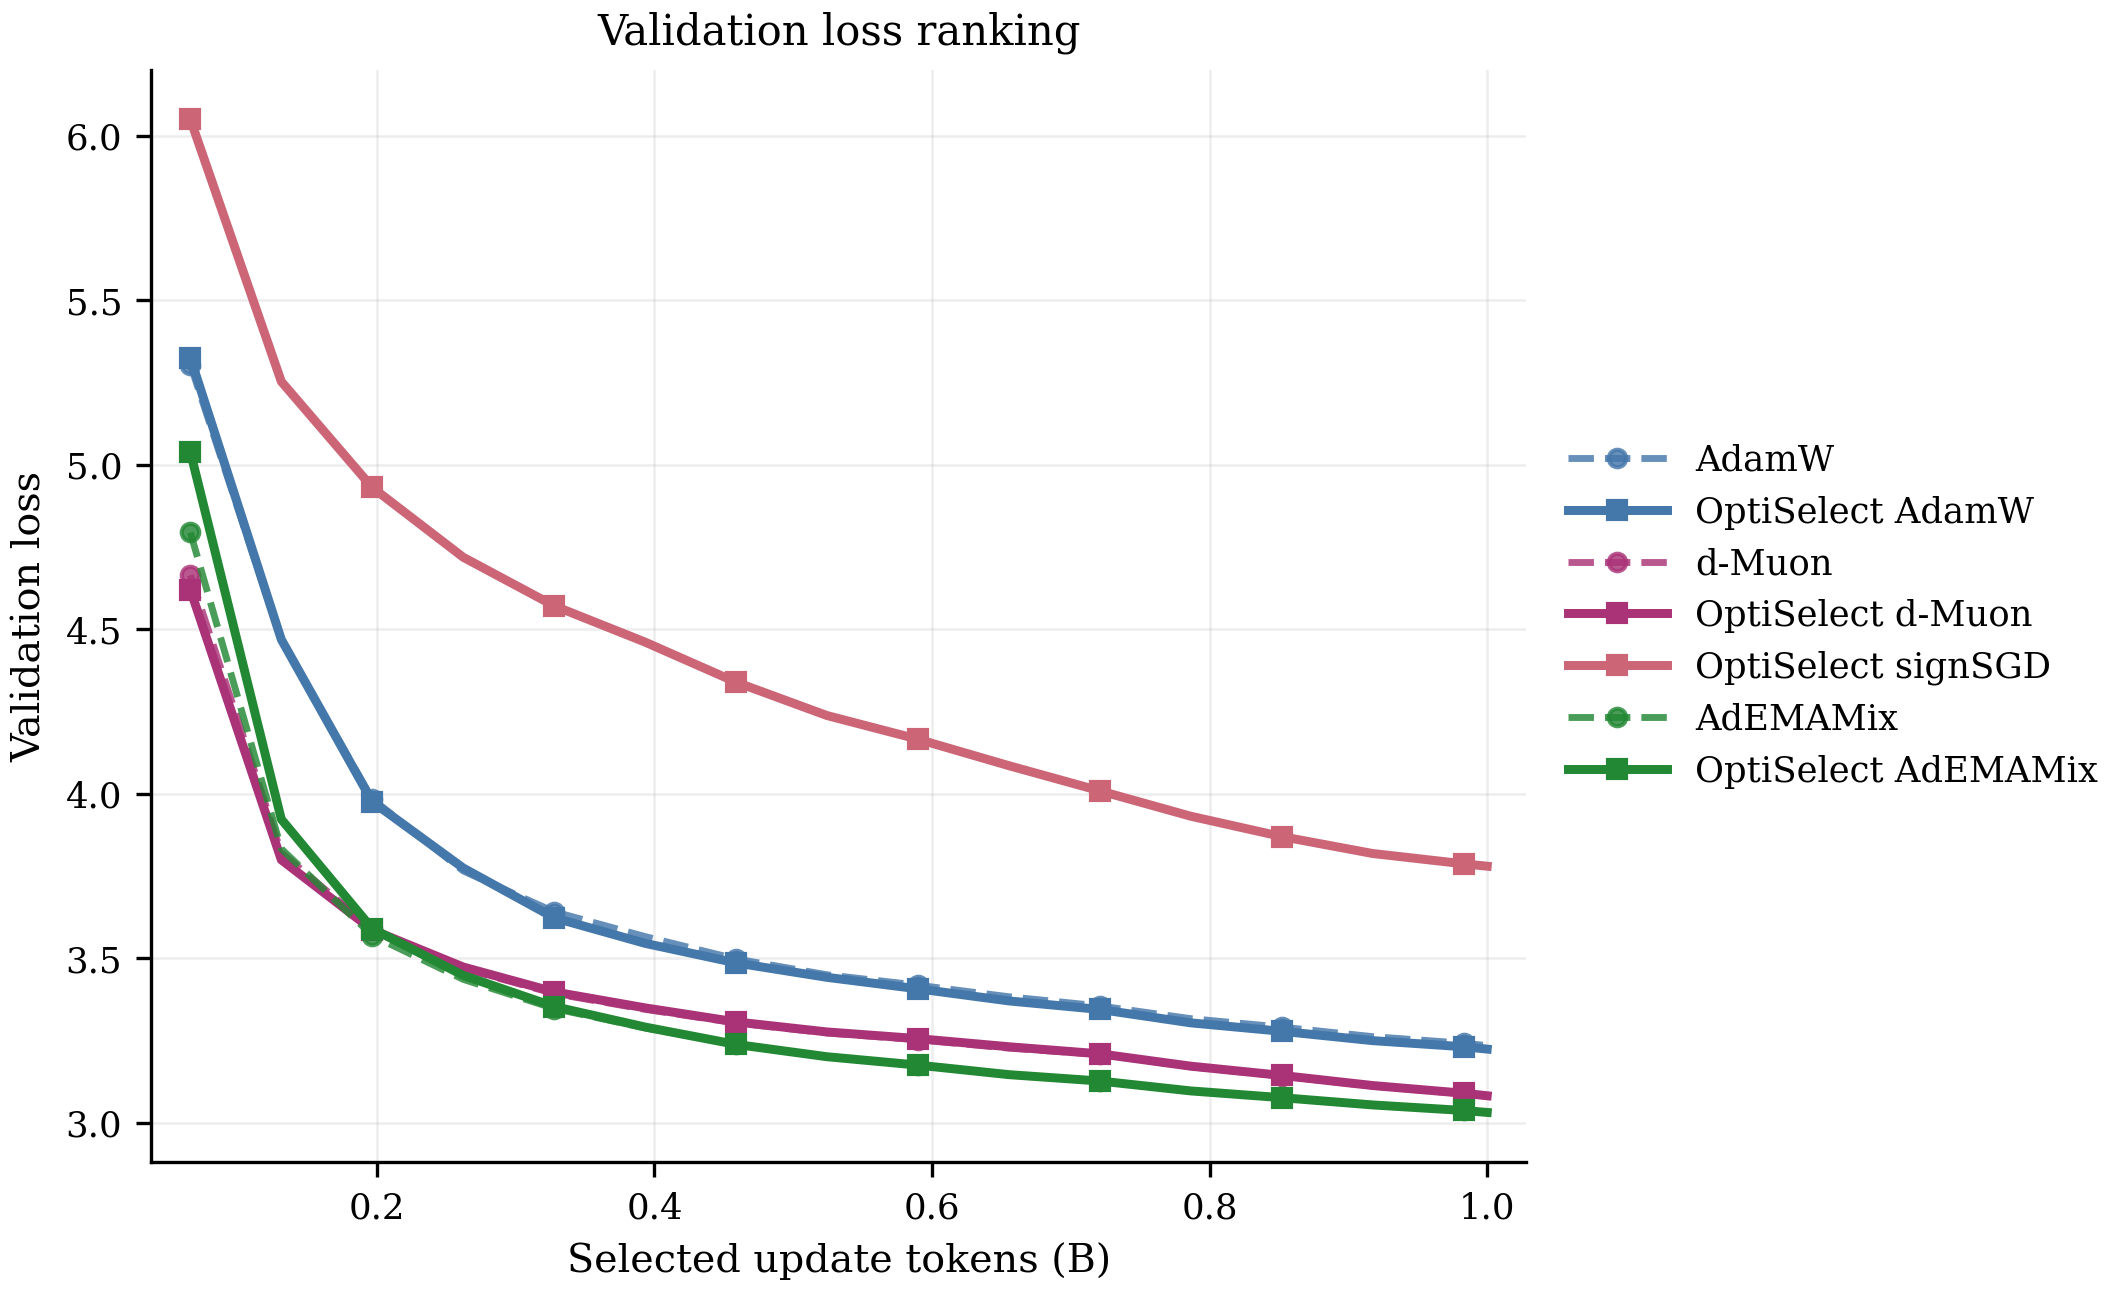

### `ranking_val_loss_vs_processed_tokens.png`

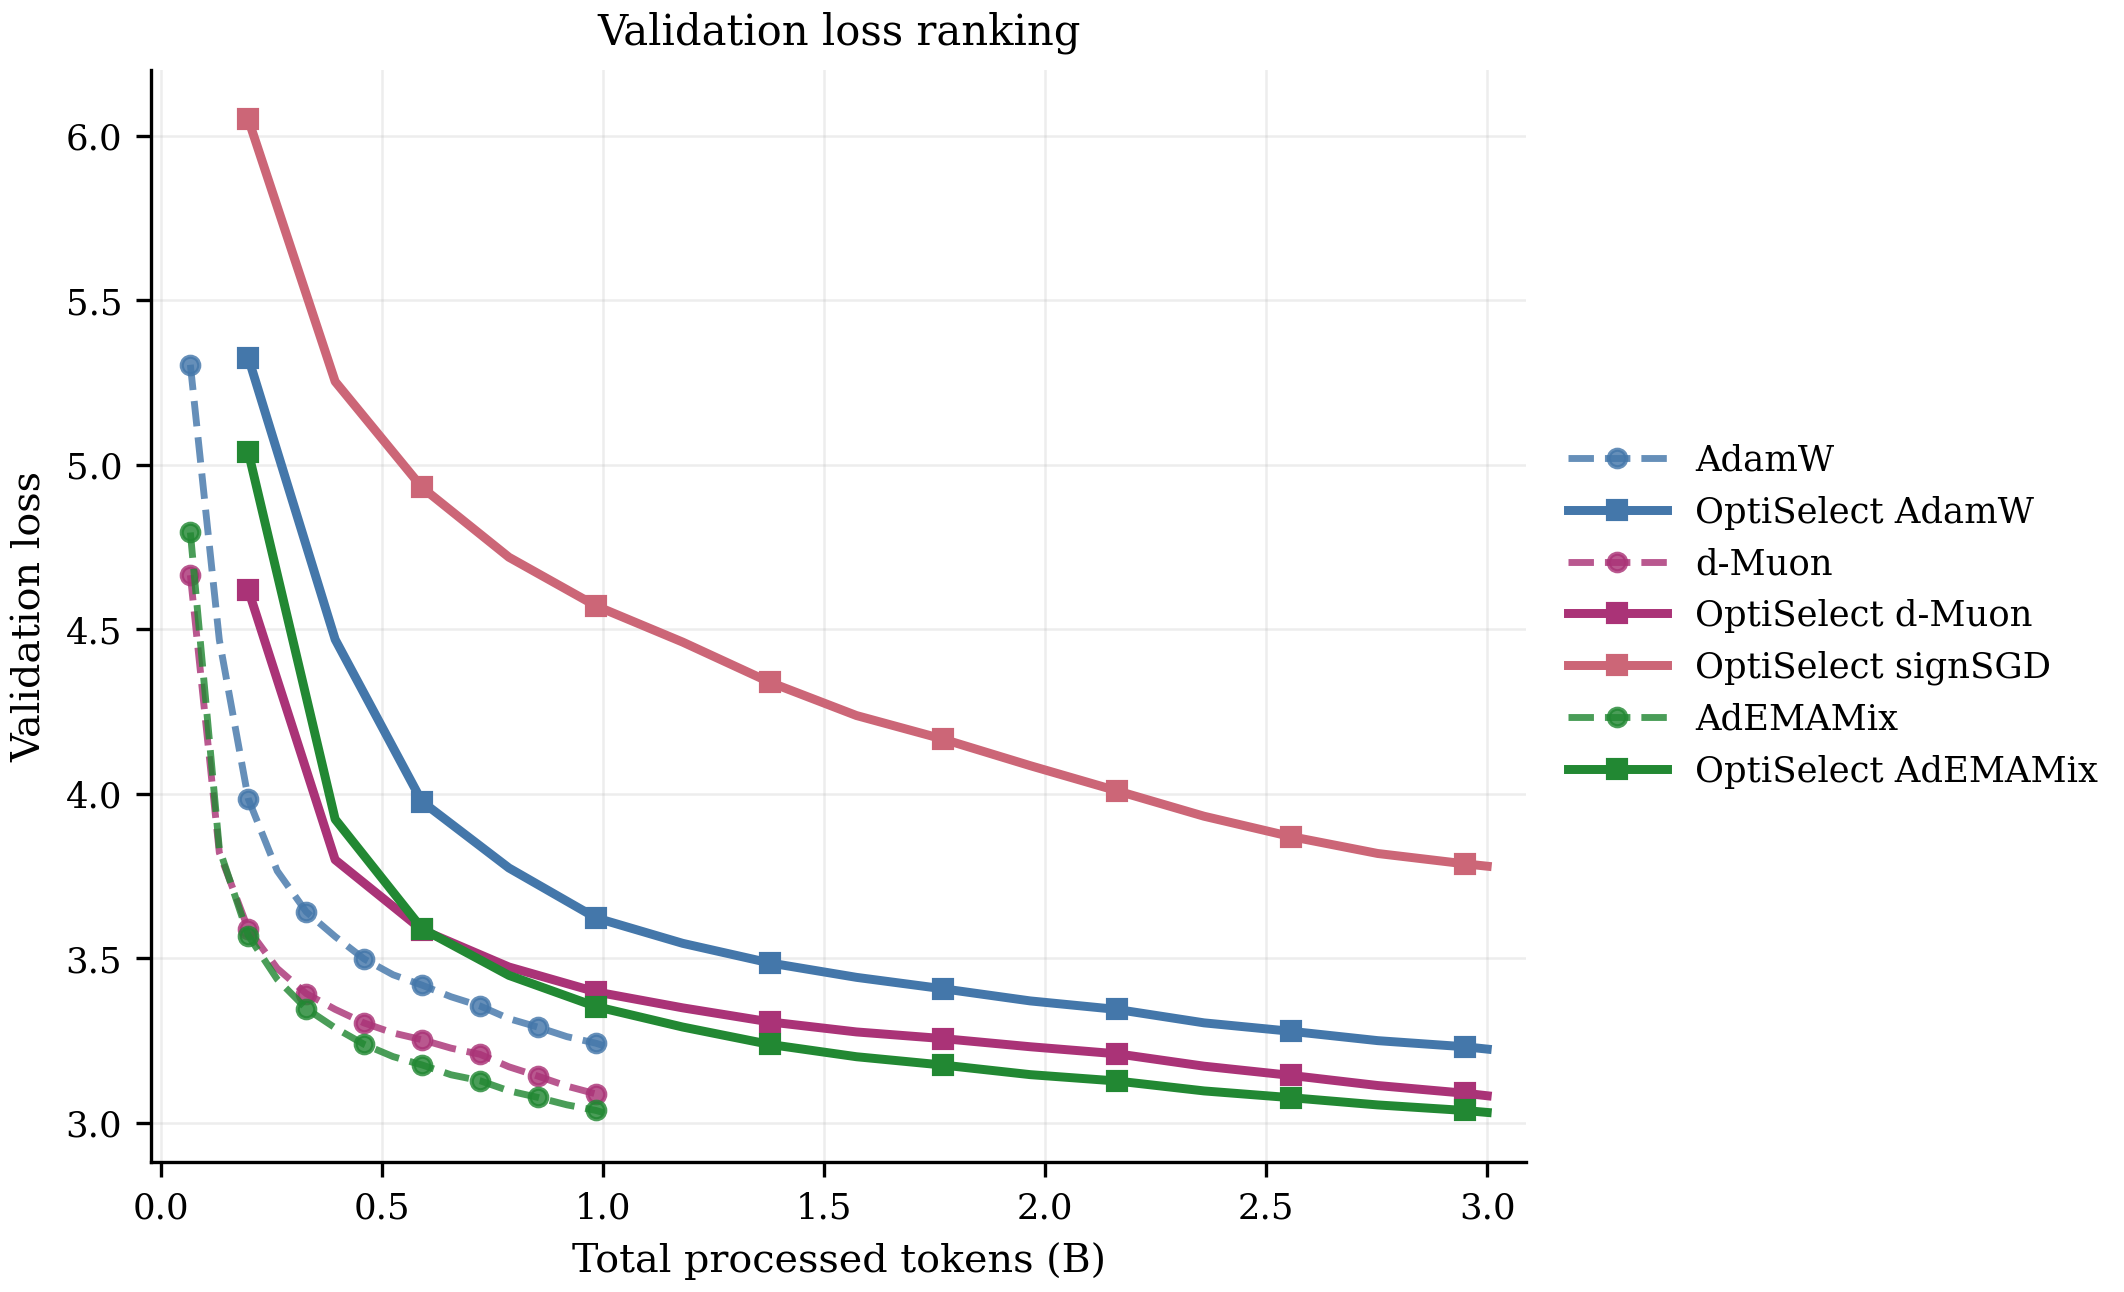

### `ranking_val_loss_vs_iterations.png`

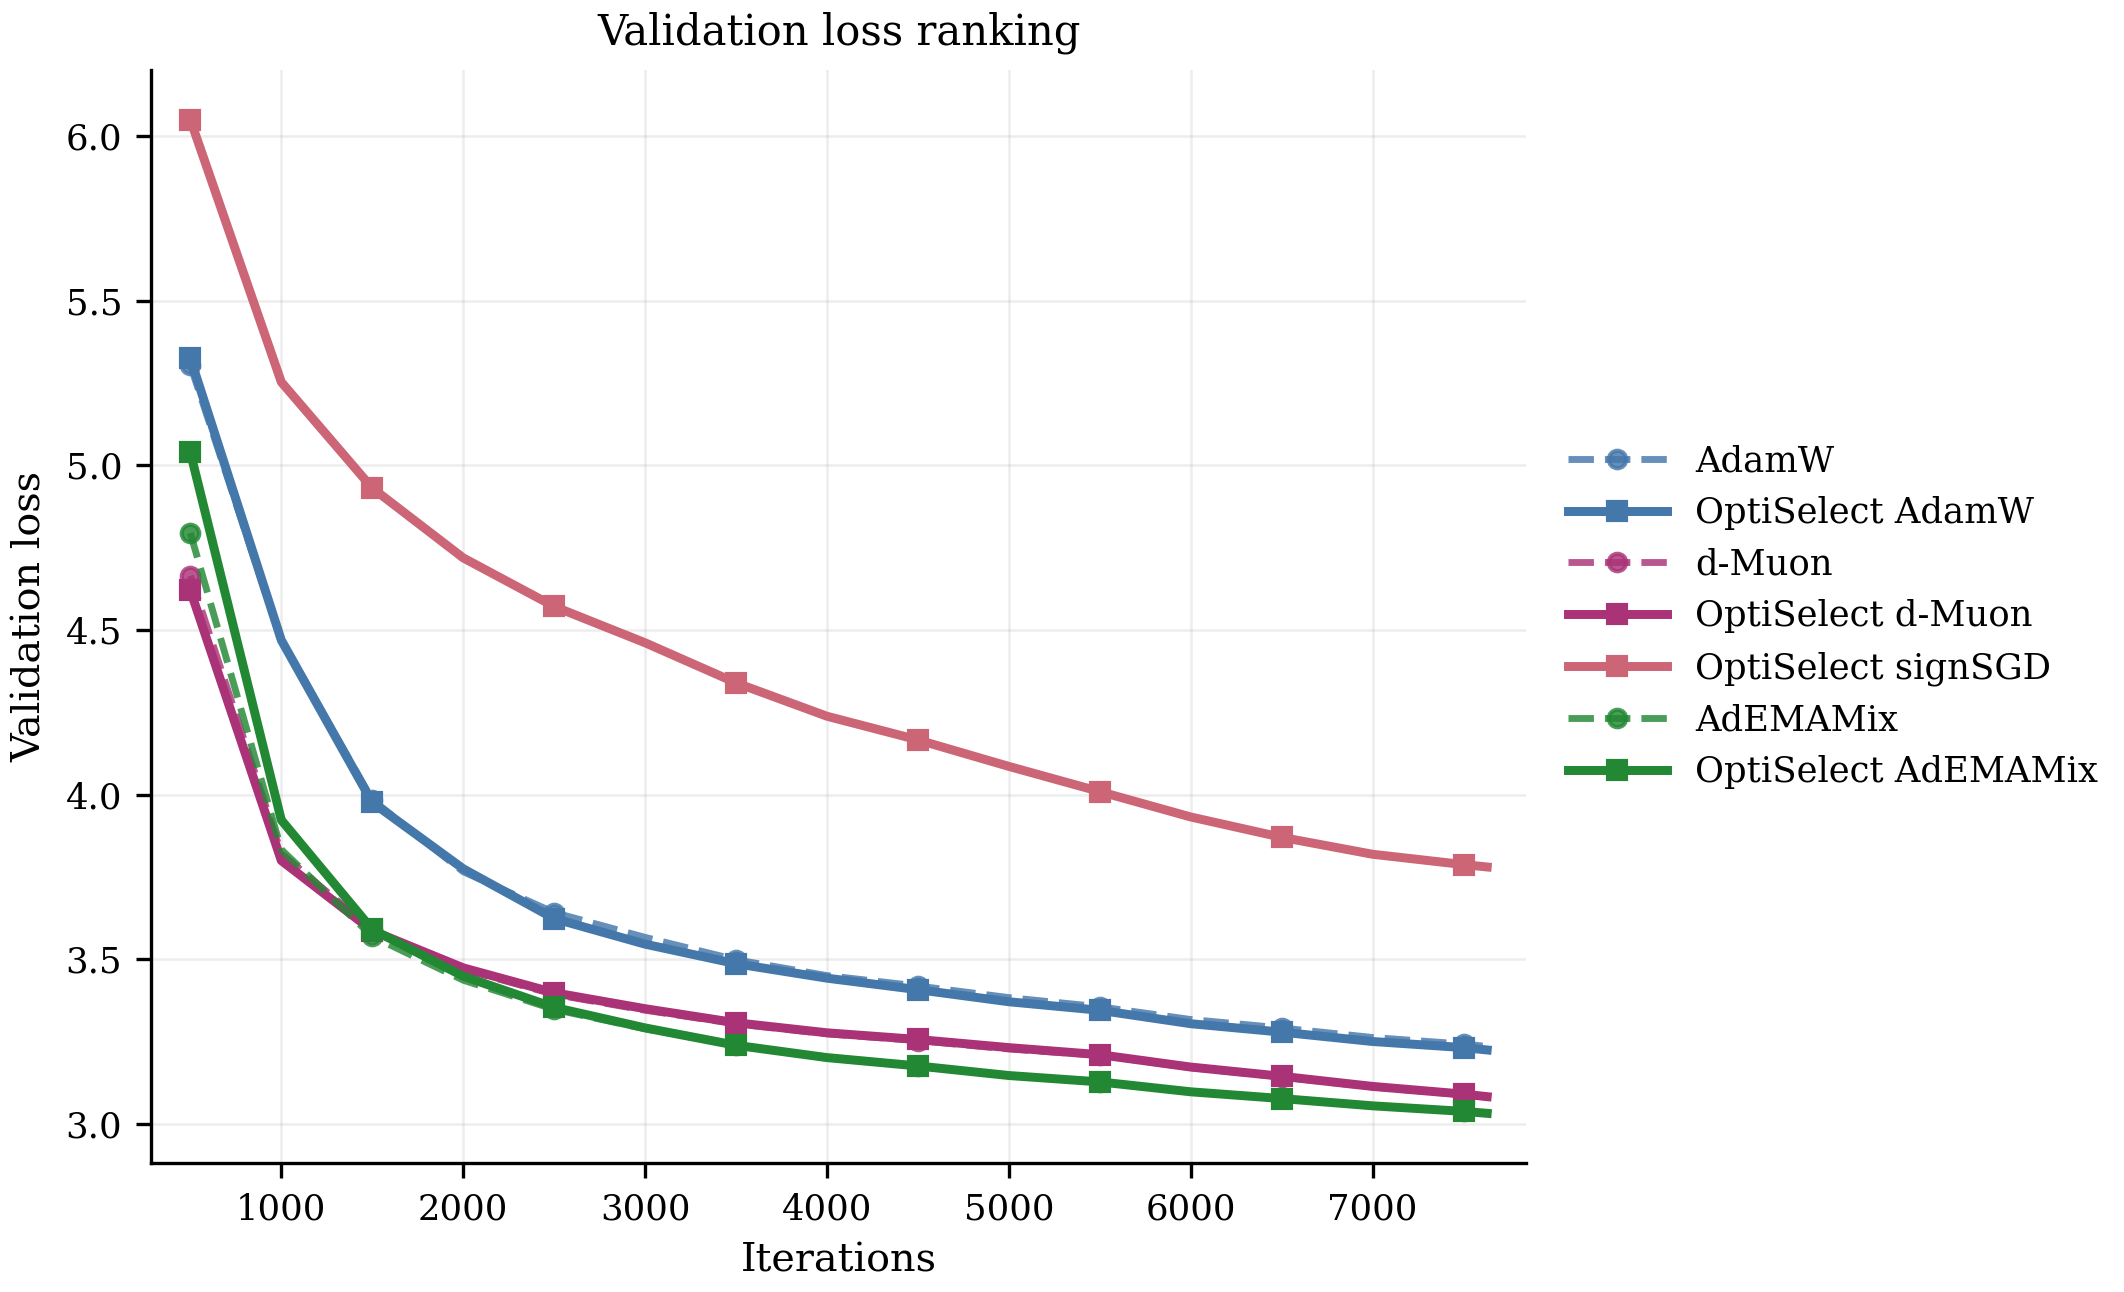

### `ranking_val_ppl_vs_update_tokens.png`

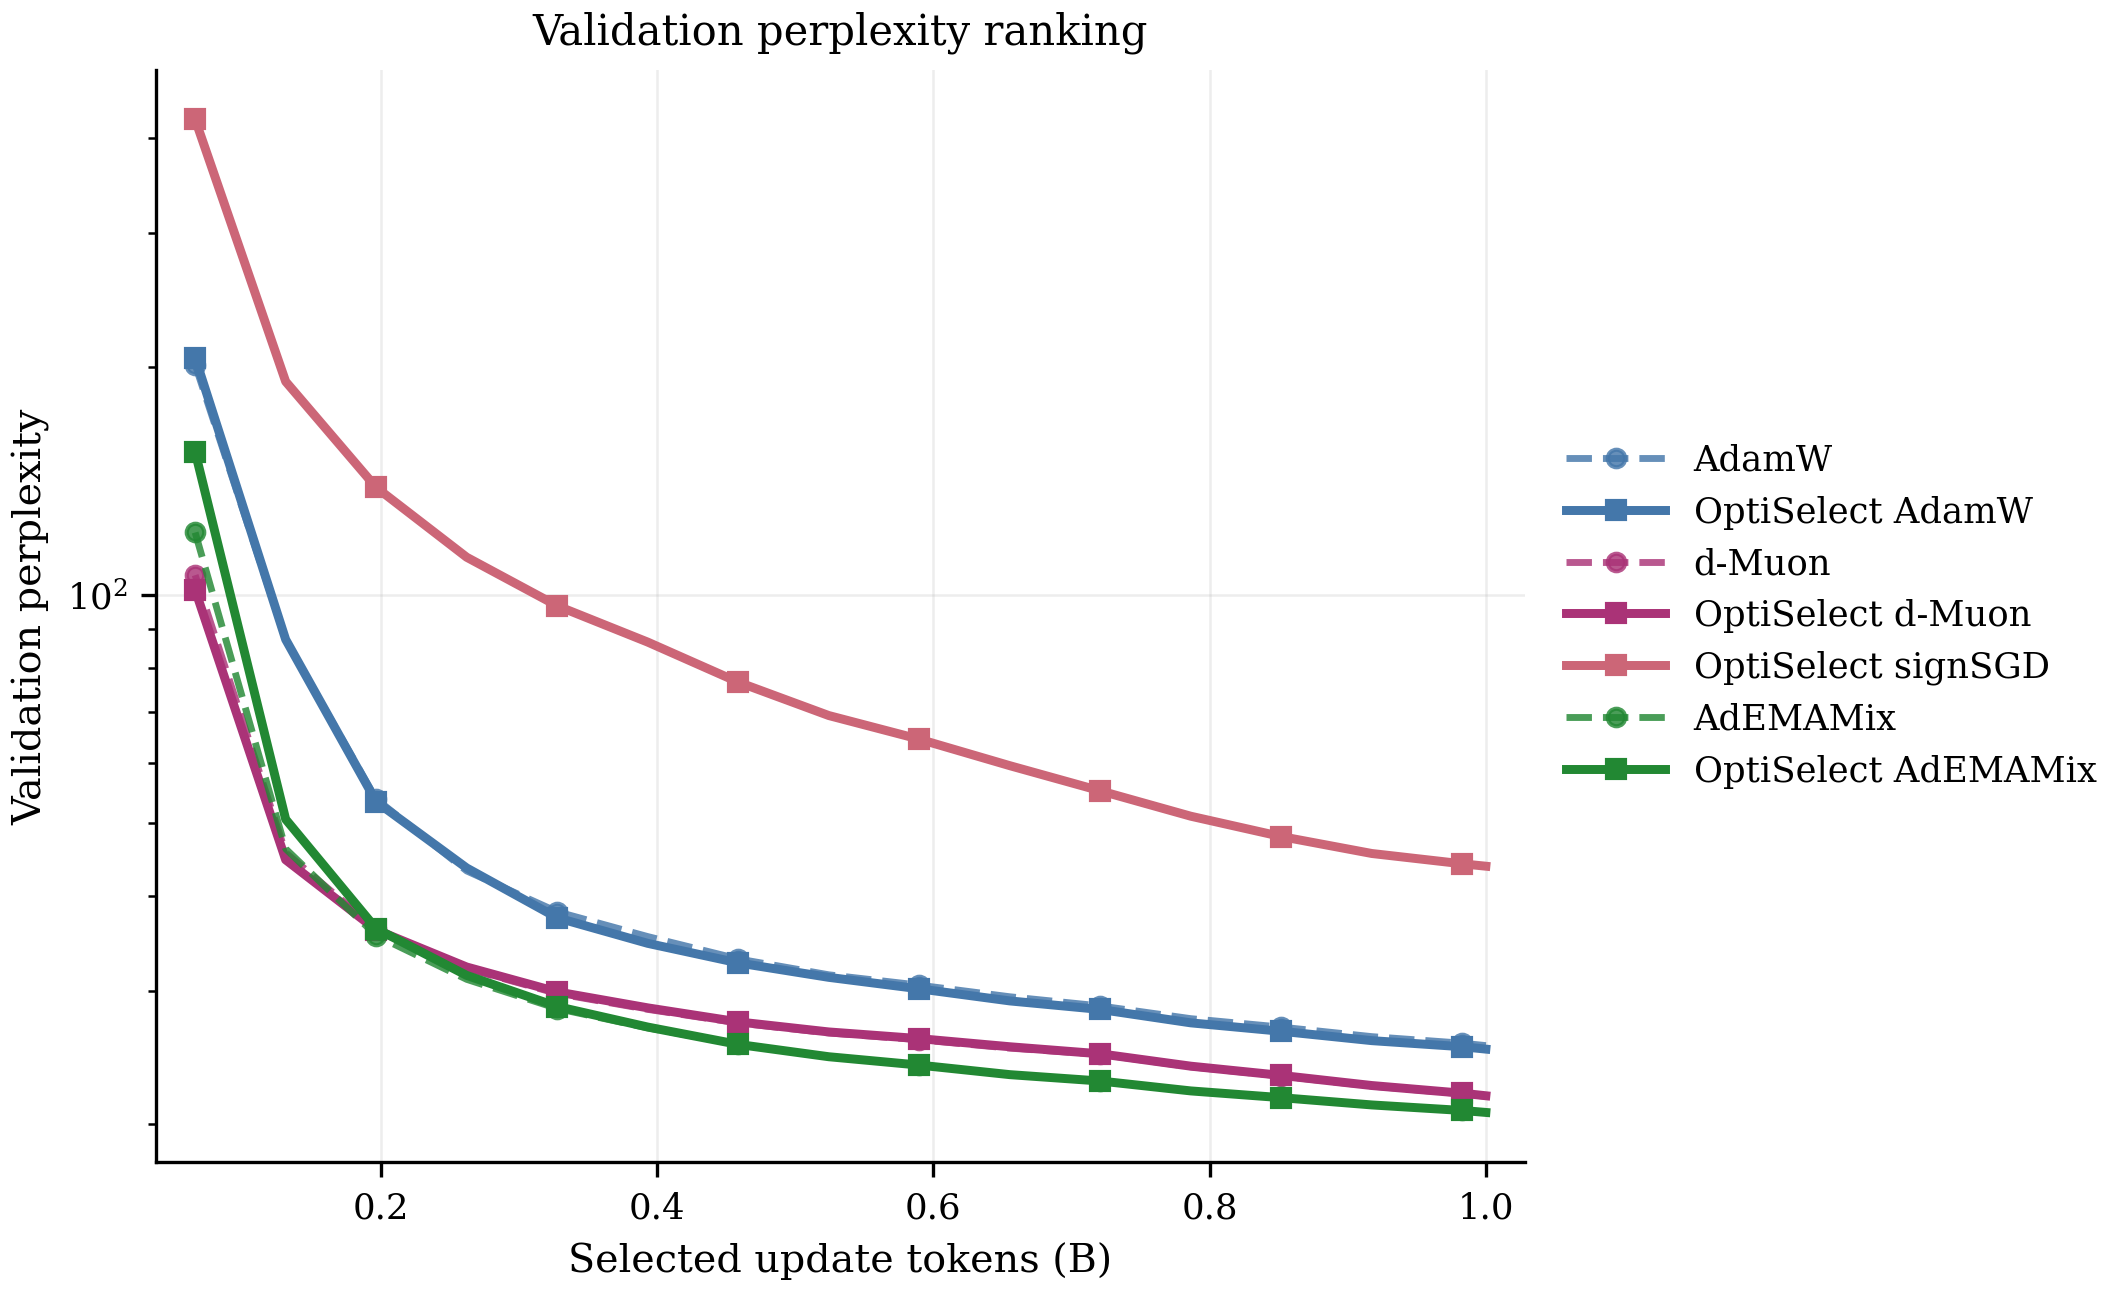

### `final_val_loss_bars.png`

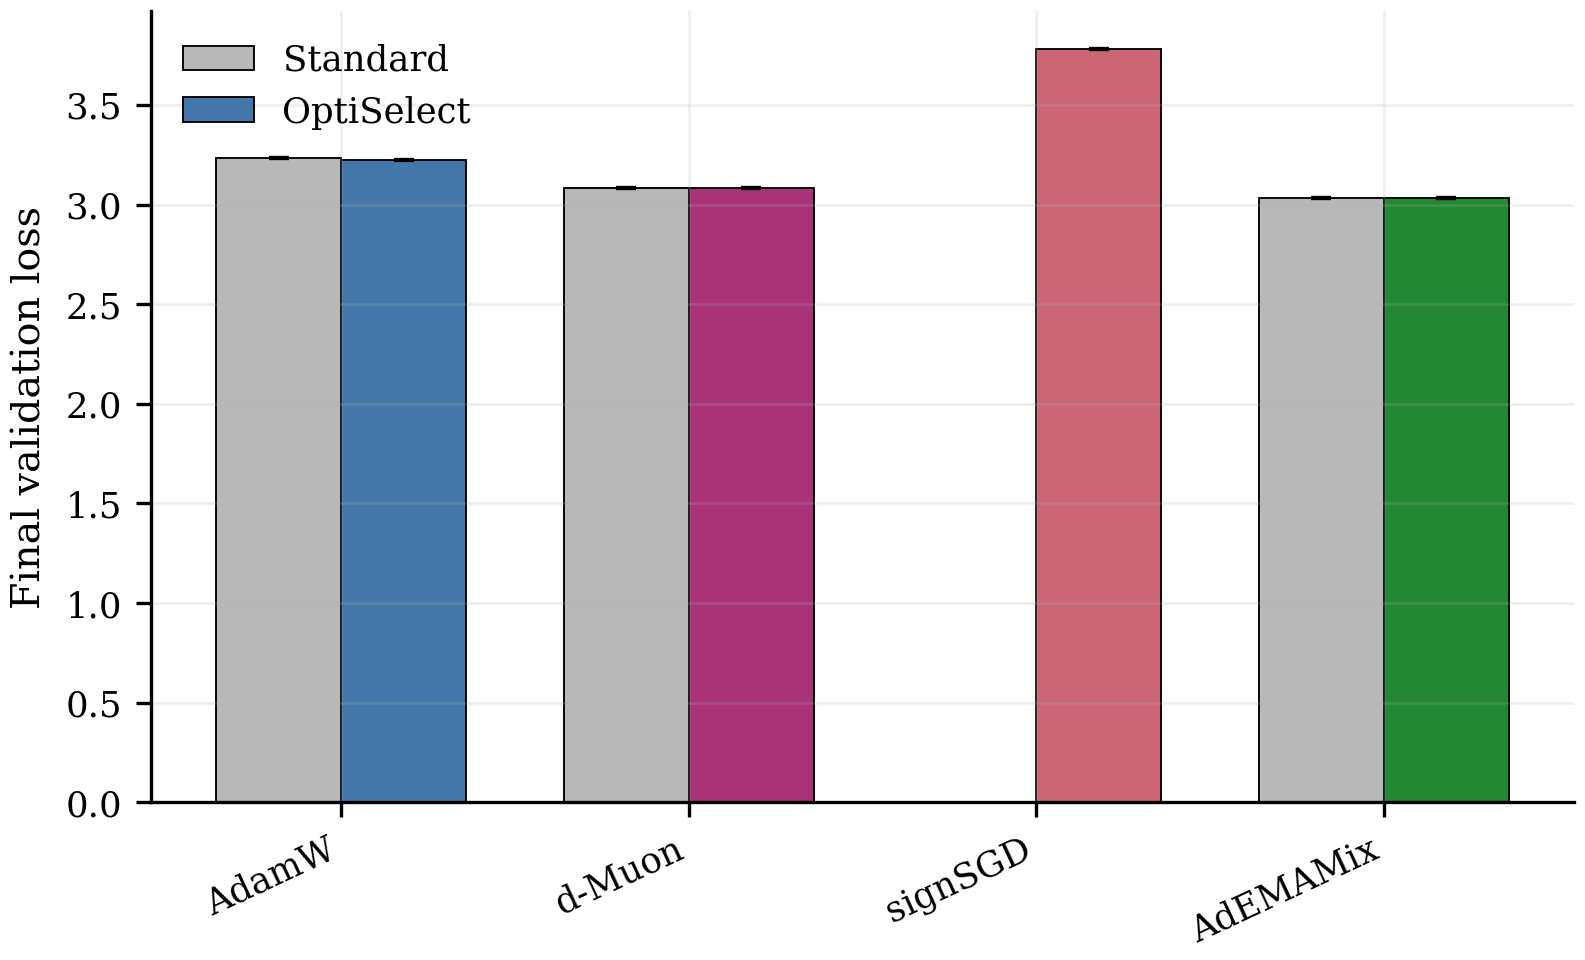

### `optiselect_vs_standard_ratios.png`

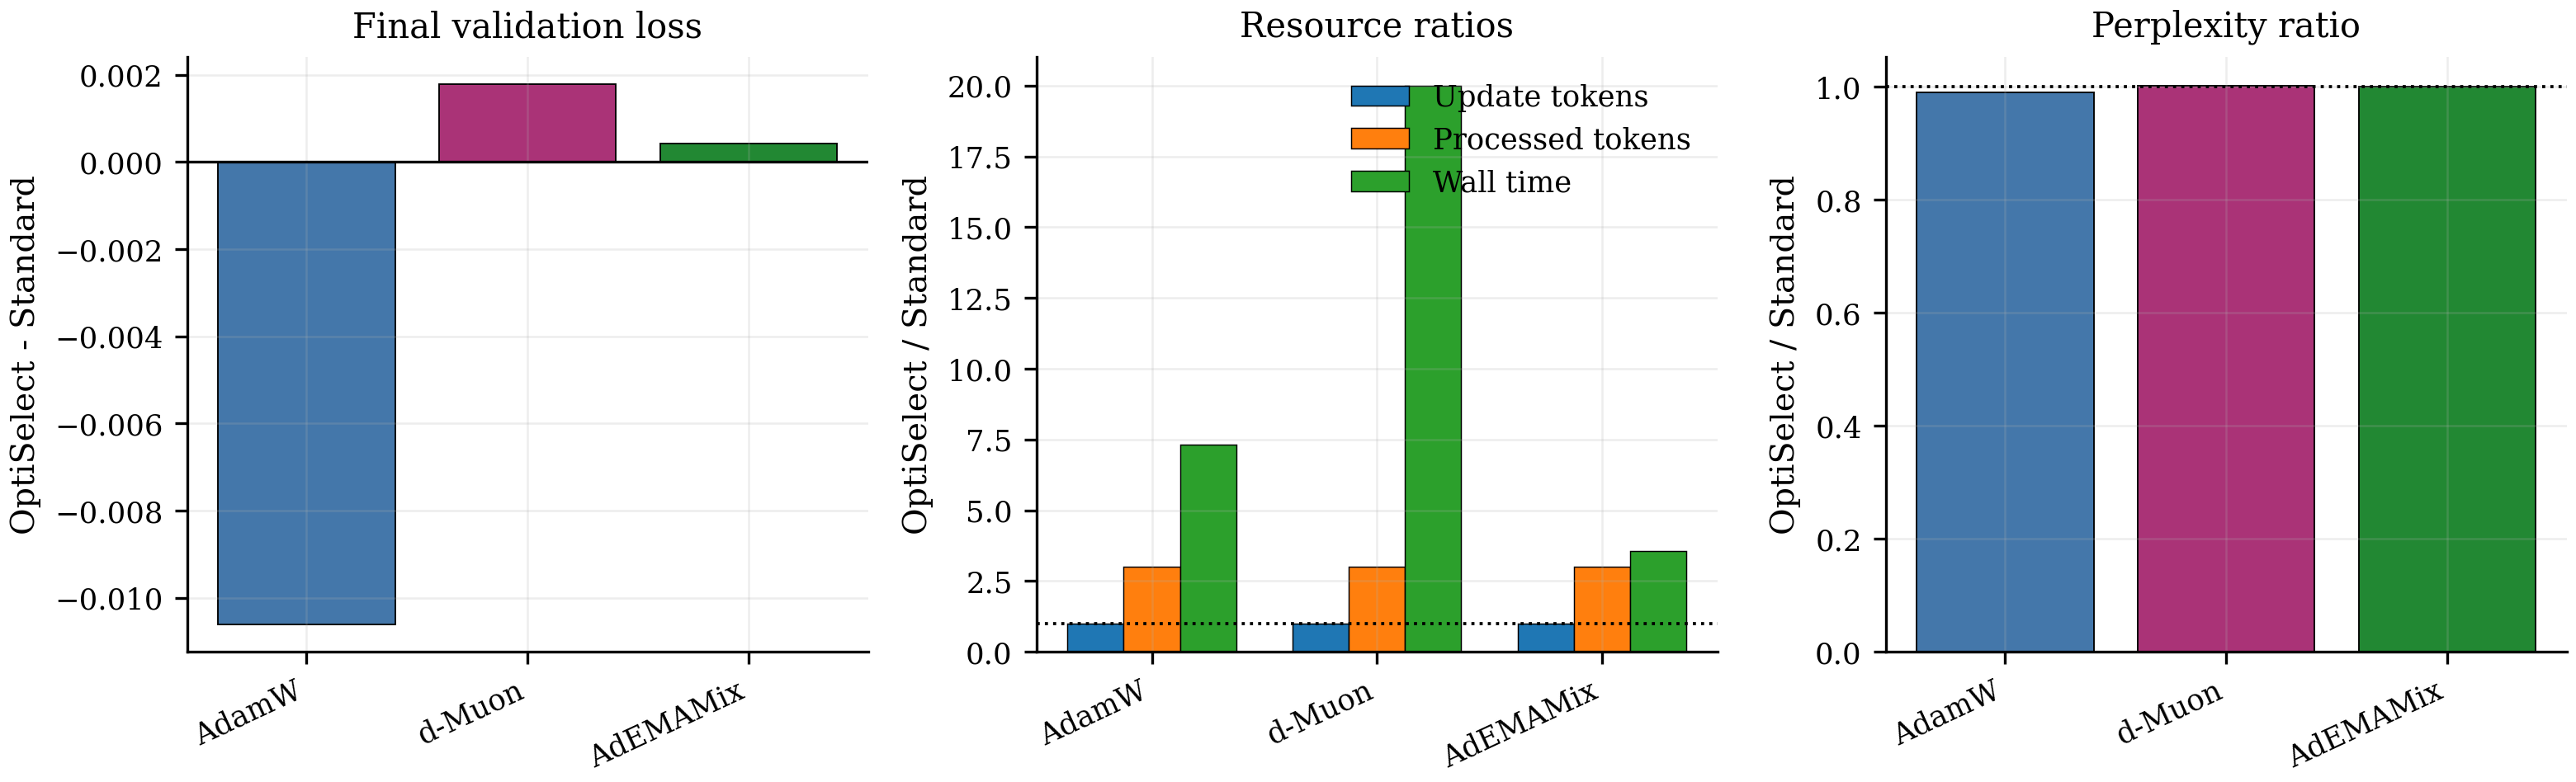

In [5]:
preview_names = [
    "ranking_val_loss_vs_update_tokens.png",
    "ranking_val_loss_vs_processed_tokens.png",
    "ranking_val_loss_vs_iterations.png",
    "ranking_val_ppl_vs_update_tokens.png",
    "final_val_loss_bars.png",
    "optiselect_vs_standard_ratios.png",
]

for name in preview_names:
    path = OUTPUT_DIR / name
    if path.exists():
        display(Markdown(f"### `{name}`"))
        display(Image(filename=str(path)))

## 3. Optional lm-evaluation-harness Results

If `lm_eval*.json` files are present inside the selected result directories, this cell loads and plots their primary metrics. For rigorous reporting, keep each lm-eval JSON tied to the exact run/checkpoint that produced it.

In [ ]:
lm_eval_df = load_lm_eval_metrics(RUN_DIRS)
if lm_eval_df.empty:
    display(Markdown("No `lm_eval*.json` files found under the requested result directories."))
else:
    display(lm_eval_df)
    lm_written = plot_lm_eval_metrics(lm_eval_df, OUTPUT_DIR, formats=FIG_FORMATS)
    display(Markdown(f"Wrote **{len(lm_written)}** lm-eval figure files."))
    for path in lm_written:
        print(path)
    preview = OUTPUT_DIR / "lm_eval_metrics.png"
    if preview.exists():
        display(Image(filename=str(preview)))

## Reporting Notes

For fair optimizer benchmarking, report both selected update tokens and processed tokens. OptiSelect typically spends extra compute/data movement on candidate scoring, so `update_tokens` and `processed_tokens` answer different but complementary questions.

Before using a figure as a final result, check that the fairness report has matching model architecture, dataset fingerprint, global batch tokens, and DDP world size. Missing standard/OptiSelect pairs are fine for diagnostics, but not enough for the paired benchmark plots.